# Internações Respiratórias RJ — Pipeline e Análise Exploratória (SUS 2012–2024)

Este notebook consolida as **internações por doenças respiratórias** (SUS) no **município do Rio de Janeiro** e prepara a **série diária de internações** para modelagem.
O foco é: leitura dos dados brutos anuais, filtros clínicos e geográficos coerentes com exposição ambiental e uma **análise exploratória inicial**.

> **Escopo**: 2012–2024, diagnósticos respiratórios (CID-10 selecionados), residentes do Rio (IBGE 330455) e permanência hospitalar > 0.

## Objetivos desta etapa
1. **Carregar** todos os CSVs anuais (2012–2024) diretamente do GitHub (*raw*).
2. **Padronizar** campos-chave (datas, CID-10) e **filtrar** registros de interesse.
3. **Construir** a série **diária** de internações (`data_dia` × `internacoes`).
4. **Explorar** o comportamento da série (tendência, sazonalidade, distribuição) e variáveis-chave (idade, permanência).
5. **Salvar** a série diária para uso posterior na modelagem.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## Carregamento e Unificação das Estações

Nesta etapa:

- **Origem:** `data/datasus/Ano/dados_filtrados_{ANO}.csv` (2012–2024) no branch `refs/heads/main`.
- **Concatenação:** une todos os anos com `ignore_index=True`.

In [3]:
anos = range(2012, 2025)
tpl = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_{ano}.csv"

dfs = []
for ano in anos:
    url = tpl.format(ano=ano)
    print(f"Lendo: {url}")
    df = pd.read_csv(url, encoding="utf-8")
    df["ano_arquivo"] = ano
    dfs.append(df)

df_sus = pd.concat(dfs, ignore_index=True)


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2012.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2013.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2014.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2015.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_28560\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2016.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_28560\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2017.csv


...

C:\Users\jhter\AppData\Local\Temp\ipykernel_28560\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2023.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_28560\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2024.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_28560\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


## Inspeção inicial

Visão geral de dimensões, tipos, amostra e dados ausentes. A coluna de data principal
virá de `DT_INTER` (quando numérica tipo `YYYYMMDD`) ou de `data_formatada` (se já estiver disponível).

In [4]:
print("Dimensões:", df_sus.shape)

print("\nTipos:")
print(df_sus.dtypes)

print("\nAmostra:")
display(df_sus.head(10))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_sus.isna().sum().sort_values(ascending=False)
na_perc   = (df_sus.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (5002306, 21)

Tipos:
UF_ZI              int64
ANO_CMPT           int64
MES_CMPT           int64
MUNIC_RES          int64
MUNIC_MOV          int64
CEP                int64
NASC               int64
SEXO               int64
DT_INTER           int64
DT_SAIDA           int64
DIAG_PRINC        object
DIAG_SECUN        object
IDADE              int64
COD_IDADE          int64
RACA_COR           int64
ETNIA              int64
DIAS_PERM          int64
MORTE              int64
CID_MORTE         object
data_formatada    object
ano_arquivo        int64
dtype: object

Amostra:


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,CEP,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,ano_arquivo
0,330455,2012,3,330350,330455,26272200,19550818,1,20120101,20120114,J189,R060,56,4,1,0,13,1,J960,2012-01-01,2012
1,330250,2012,1,330250,330250,25915000,19310415,3,20120101,20120110,J188,NaN,80,4,99,0,9,1,J188,2012-01-01,2012
2,330455,2012,3,330455,330455,20020030,20030802,1,20120101,20120103,J351,NaN,8,4,99,0,2,0,NaN,2012-01-01,2012
3,330455,2012,3,330455,330455,20720000,20031021,1,20120101,20120104,J353,NaN,8,4,3,0,3,0,NaN,2012-01-01,2012
4,330455,2012,2,330455,330455,21040300,19220324,3,20120101,20120131,J448,NaN,89,4,1,0,30,0,NaN,2012-01-01,2012
5,330000,2012,1,330475,330475,28230000,19401223,1,20120101,20120103,J189,NaN,71,4,1,0,2,0,NaN,2012-01-01,2012
6,330455,2012,1,330455,330455,22773360,19611001,1,20120101,20120110,J189,NaN,50,4,1,0,9,0,NaN,2012-01-01,2012
7,330455,2012,4,330455,330455,21070061,20061006,1,20120101,20120108,J180,NaN,5,4,3,0,7,0,NaN,2012-01-01,2012
8,330010,2012,1,330010,330010,23900620,20110129,3,20120101,20120105,J189,NaN,11,3,99,0,4,0,NaN,2012-01-01,2012
9,330455,2012,4,330455,330455,21070061,19400425,1,20120101,20120218,J180,NaN,71,4,3,0,48,1,A419,2012-01-01,2012



Valores ausentes por coluna (top 20):


,NA_count,NA_%
DIAG_SECUN,1931998,38.62
CID_MORTE,1833890,36.66
MES_CMPT,0,0.00
ANO_CMPT,0,0.00
UF_ZI,0,0.00
MUNIC_MOV,0,0.00
MUNIC_RES,0,0.00
SEXO,0,0.00
CEP,0,0.00
DT_INTER,0,0.00


In [5]:
df_sus['DIAG_PRINC'].unique()

array(['J189', 'J188', 'J351', 'J353', 'J448', 'J180', 'J81 ', 'J960',
       'J128', 'J158', 'J449', 'J40 ', 'J100', 'J459', 'J348', 'J219',
       'J110', 'J46 ', 'J80 ', 'J341', 'J039', 'J938', 'J438', 'J65 ',
       'J440', 'J931', 'J168', 'J849', 'J410', 'J159', 'J181', 'J690',
       'J869', 'J91 ', 'J930', 'J381', 'J350', 'J984', 'J129', 'J330',
       'J90 ', 'J324', 'J985', 'J439', 'J171', 'J36 ', 'J156', 'J152',
       'J218', 'J983', 'J342', 'J969', 'J942', 'J709', 'J069', 'J019',
       'J202', 'J441', 'J122', 'J47 ', 'J458', 'J210', 'J030', 'J151',
       'J390', 'J320', 'J042', 'J42 ', 'J068', 'J13 ', 'J961', 'J949',
       'J958', 'J352', 'J358', 'J170', 'J860', 'J450', 'J851', 'J955',
       'J040', 'J64 ', 'J359', 'J328', 'J431', 'J120', 'J853', 'J178',
       'J948', 'J852', 'J385', 'J941', 'J121', 'J451', 'J041', 'J840',
       'J391', 'J182', 'J338', 'J959', 'J398', 'J322', 'J060', 'J848',
       'J323', 'J154', 'J339', 'J384', 'J841', 'J343', 'J029', 'J010',
      

## Limpeza de CID-10 e filtros

- `DIAG_PRINC` normalizado (maiúsculas; remove pontos/hífens).  
- `CID_PREFIXO` = 3 primeiros caracteres.  
- **Filtro clínico** (associado à poluição): **J40–J46** (bronquites, DPOC/enfisema, asma).  
- **Filtro geográfico**: residentes do Rio (`MUNIC_RES == 330455`).  
- **Filtro de permanência**: `DIAS_PERM > 0`.

In [6]:
cids_associados_a_poluicao = {
    "J40", "J41", "J42",  # bronquites
    "J43", "J44",         # enfisema / DPOC
    "J45", "J46"          # asma / status asmático
}

col_diag = "DIAG_PRINC"  
df_sus[col_diag] = df_sus[col_diag].astype(str).str.upper().str.strip()

# Remove caracteres não alfanuméricos 
df_sus[col_diag] = df_sus[col_diag].str.replace(r"[^A-Z0-9]", "", regex=True)

# Prefixo CID: 3 primeiros caracteres
df_sus["CID_PREFIXO"] = df_sus[col_diag].str[:3]

sus_filtrado = df_sus[df_sus["CID_PREFIXO"].isin(cids_associados_a_poluicao)].copy()

grupo_map = {
    "J40": "BRONQUITE",
    "J41": "BRONQUITE",
    "J42": "BRONQUITE",
    "J43": "DPOC/ENFISEMA",
    "J44": "DPOC",
    "J45": "ASMA",
    "J46": "ASMA"
}
sus_filtrado["GRUPO_CID"] = sus_filtrado["CID_PREFIXO"].map(grupo_map)

print(sus_filtrado.shape)
print(sus_filtrado["CID_PREFIXO"].value_counts())
display(sus_filtrado.head())

(694519, 23)
CID_PREFIXO
J45    252839
J44    215236
J40    103721
J46     48549
J43     41336
J41     24823
J42      8015
Name: count, dtype: int64


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,CEP,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,ano_arquivo,CID_PREFIXO,GRUPO_CID
4,330455,2012,2,330455,330455,21040300,19220324,3,20120101,20120131,J448,NaN,89,4,1,0,30,0,NaN,2012-01-01,2012,J44,DPOC
16,330490,2012,2,330490,330490,24720000,19530210,1,20120101,20120105,J449,NaN,58,4,3,0,4,0,NaN,2012-01-01,2012,J44,DPOC
18,330250,2012,1,330250,330250,25930000,20101005,1,20120101,20120103,J40,NaN,1,4,99,0,2,0,NaN,2012-01-01,2012,J40,BRONQUITE
23,330455,2012,3,330455,330455,21860050,19461116,3,20120101,20120124,J449,NaN,65,4,2,0,23,0,NaN,2012-01-01,2012,J44,DPOC
24,330000,2012,2,330015,330015,28495000,19300705,1,20120101,20120102,J459,NaN,81,4,1,0,1,0,NaN,2012-01-01,2012,J45,ASMA


In [7]:
#@title Filtrando pelos municípios de interesse (Niterói, São Gonçalo, Magé, Itaboraí, Maricá, Queimados, Duque de Caxias, Mesquita, Nilópolis, Belford Roxo, São João de Meriti, Nova Iguaçu, Rio de Janeiro)

municipios_interesse = [330455, 330510, 330320, 330285, 330045, 330350, 330170]

municipios_rio_de_janeiro = [330455]

sus_filtrado = sus_filtrado[sus_filtrado['MUNIC_RES'].isin(municipios_interesse)]

print("Dimensões após filtro por municípios:", sus_filtrado.shape)

Dimensões após filtro por municípios: (126217, 23)


In [8]:
sus_filtrado = sus_filtrado[sus_filtrado['DIAS_PERM'] > 0]
print("Dimensões após filtro por permanência:", sus_filtrado.shape)

Dimensões após filtro por permanência: (124014, 23)



## Série diária de internações

Contagem de internações por **dia**, preenchendo lacunas do calendário com zero e calculando uma **média móvel de 7 dias** para leitura visual.


In [9]:
sus_filtrado = sus_filtrado.copy()
sus_filtrado["data_dia"] = pd.to_datetime(sus_filtrado["data_formatada"], errors="coerce").dt.normalize()
sus_filtrado = sus_filtrado.dropna(subset=["data_dia"])

internacoes_diario = (
    sus_filtrado.groupby("data_dia")
    .size()
    .rename("num_internacoes")
    .astype("int64")
    .reset_index()
    .sort_values("data_dia")
)

# 3) Preencher calendário (datas faltantes -> 0 internações)
idx_full = pd.date_range(internacoes_diario["data_dia"].min(),
                         internacoes_diario["data_dia"].max(),
                         freq="D")

internacoes_rj = (
    internacoes_diario.set_index("data_dia")
    .reindex(idx_full, fill_value=0)
    .rename_axis("data_dia")
    .reset_index()
)

internacoes_rj["internacoes_d1"] = internacoes_rj["num_internacoes"].shift(-1)
internacoes_rj["internacoes_d7"] = internacoes_rj["num_internacoes"].shift(-7)

project_root = Path().resolve().parents[2]  
output_dir = project_root / "data" / "datasus"
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_DOENCA_RESP_RJ.csv"
internacoes_rj.to_csv(output_csv_path, index=False, encoding="utf-8")

# Contagem de dias com 0 internações
qtd_zeros = int((internacoes_rj["num_internacoes"] == 0).sum())
print(f"Arquivo salvo em: {output_csv_path}")
print(f"Dias com 0 internações: {qtd_zeros}")
print(internacoes_rj.head())


Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\datasus\INTERNACOES_DOENCA_RESP_RJ.csv
Dias com 0 internações: 228
    data_dia  num_internacoes  internacoes_d1  internacoes_d7
0 2012-01-01              143             0.0            13.0
1 2012-01-02                0            65.0            65.0
2 2012-01-03               65            39.0            65.0
3 2012-01-04               39            52.0            26.0
4 2012-01-05               52            26.0            39.0


In [11]:
internacoes_rj["internacoes_mm7"] = internacoes_rj["num_internacoes"].rolling(7, min_periods=1).mean()

display(internacoes_rj.head())

,data_dia,num_internacoes,internacoes_d1,internacoes_d7,internacoes_mm7
0,2012-01-01,143,0.0,13.0,143.000000
1,2012-01-02,0,65.0,65.0,71.500000
2,2012-01-03,65,39.0,65.0,69.333333
3,2012-01-04,39,52.0,26.0,61.750000
4,2012-01-05,52,26.0,39.0,59.800000


## EDA


### Tendência temporal (série diária)

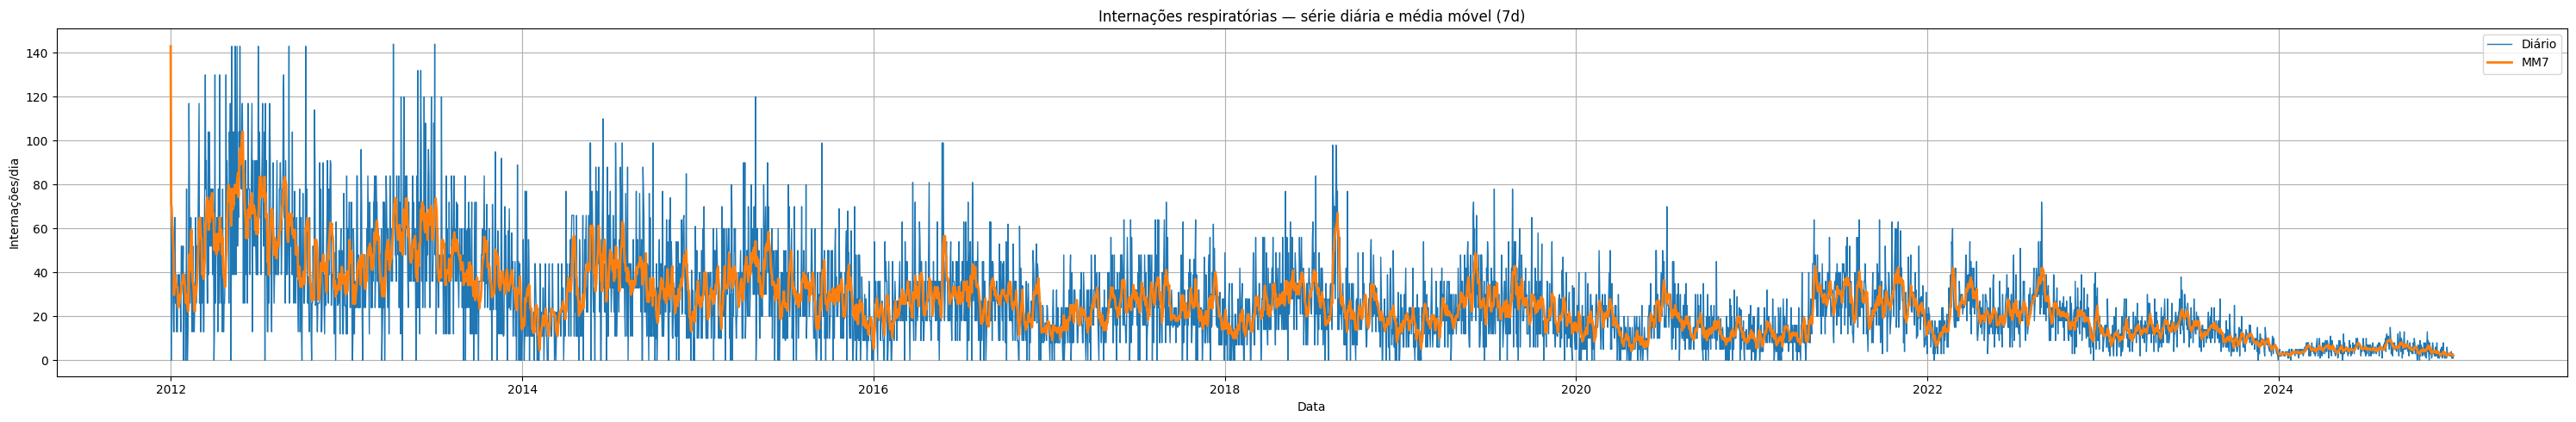

In [13]:

plt.figure(figsize=(30, 5))
plt.plot(internacoes_rj["data_dia"], internacoes_rj["num_internacoes"], linewidth=1, label="Diário")
plt.plot(internacoes_rj["data_dia"], internacoes_rj["internacoes_mm7"], linewidth=2, label="MM7")
plt.title("Internações respiratórias — série diária e média móvel (7d)")
plt.xlabel("Data")
plt.ylabel("Internações/dia")
plt.legend()
plt.tight_layout()
plt.show()


### Sazonalidade (mês e dia da semana)

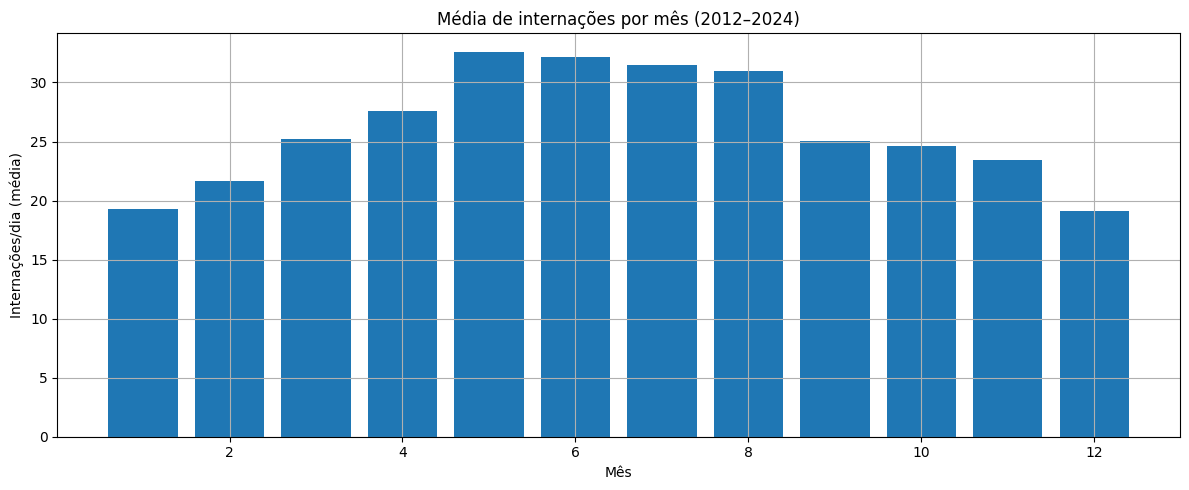

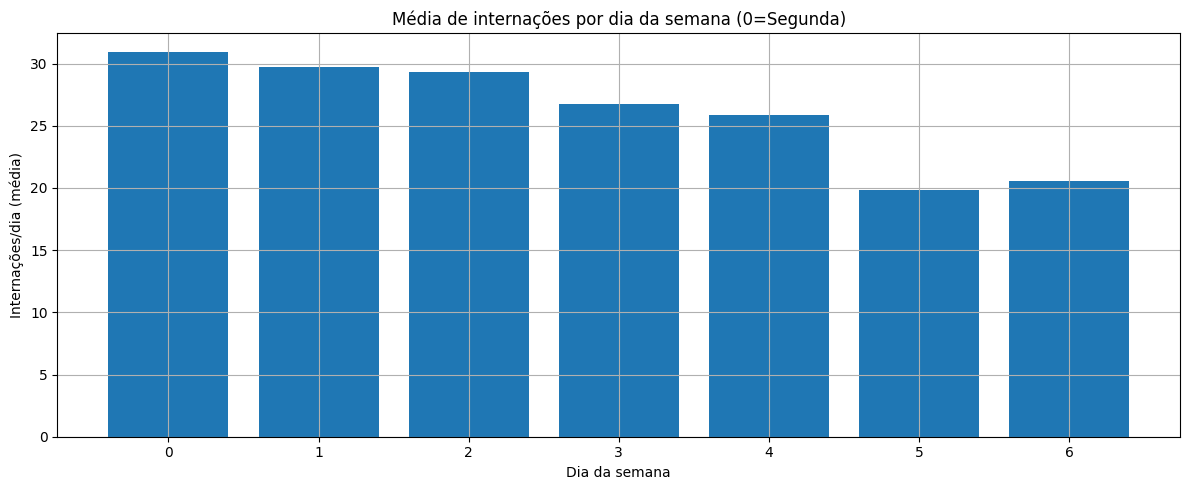

In [14]:
tmp = internacoes_rj.copy()
tmp["mes"] = tmp["data_dia"].dt.month
tmp["dow"] = tmp["data_dia"].dt.day_of_week  # 0=segunda

by_month = tmp.groupby("mes")["num_internacoes"].mean().reindex(range(1,13))
plt.figure()
plt.bar(by_month.index, by_month.values)
plt.title("Média de internações por mês (2012–2024)")
plt.xlabel("Mês")
plt.ylabel("Internações/dia (média)")
plt.tight_layout()
plt.show()

by_dow = tmp.groupby("dow")["num_internacoes"].mean().reindex(range(0,7))
plt.figure()
plt.bar(by_dow.index, by_dow.values)
plt.title("Média de internações por dia da semana (0=Segunda)")
plt.xlabel("Dia da semana")
plt.ylabel("Internações/dia (média)")
plt.tight_layout()
plt.show()



### Distribuições (idade e permanência)


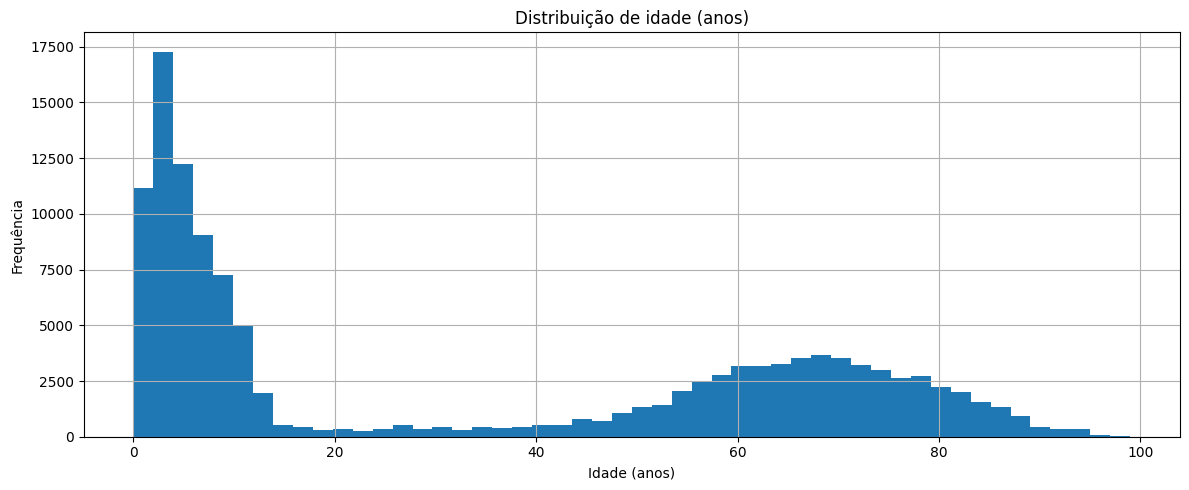

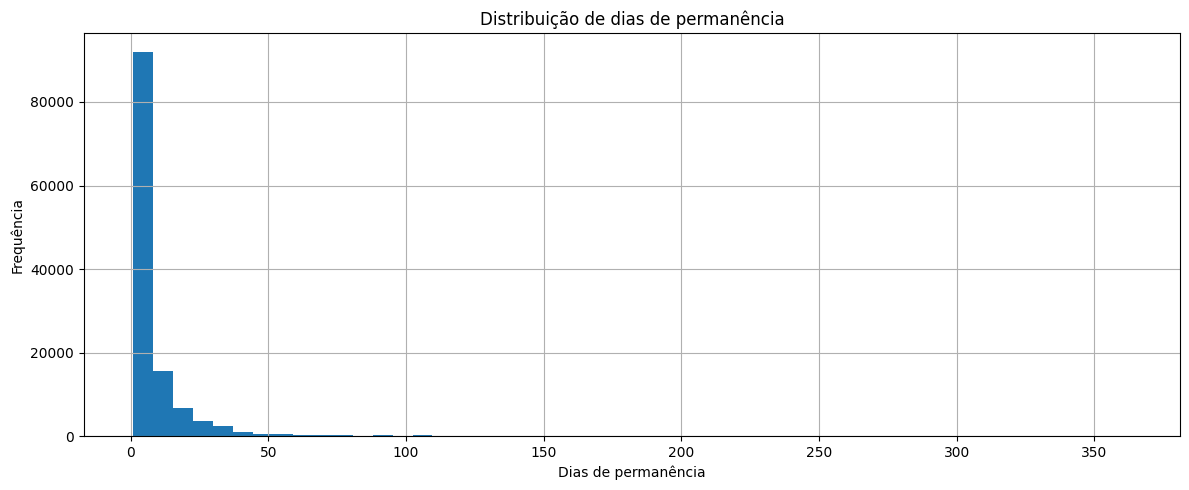

In [15]:

if "IDADE" in sus_filtrado.columns:
    x = pd.to_numeric(sus_filtrado["IDADE"], errors="coerce").dropna()
    plt.figure()
    plt.hist(x.values, bins=50)
    plt.title("Distribuição de idade (anos)")
    plt.xlabel("Idade (anos)")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

if "DIAS_PERM" in sus_filtrado.columns:
    los = pd.to_numeric(sus_filtrado["DIAS_PERM"], errors="coerce").dropna()
    plt.figure()
    plt.hist(los.values, bins=50)
    plt.title("Distribuição de dias de permanência")
    plt.xlabel("Dias de permanência")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


### Composição por diagnóstico (CID-10)

In [16]:
if "CID_PREFIXO" in sus_filtrado.columns:
    vc = sus_filtrado["CID_PREFIXO"].value_counts().sort_values(ascending=False)
    display(vc.to_frame("contagem").head(10))

,contagem
CID_PREFIXO,
J45,63248
J44,46574
J43,5981
J40,4878
J42,1467
J46,1076
J41,790
